# IST-3 Dataset Analysis

Exploratory analysis of the IST-3 trial data using the same covariates, outcome, and treatment as `IST3.ipynb`.

**Goals**:
- ATE and treatment arm balance
- Outcome heterogeneity across subgroups
- Signal-to-noise ratio: how predictable is the outcome, and how hard is CATE estimation?
- Noise analysis: residual variance after conditioning on covariates


## 1. Setup and Data Loading

In [18]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_predict, KFold, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings("ignore")

import os
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('data_analyse.ipynb')), 'data')
SAS_PATH = os.path.join(DATA_DIR, 'datashare_aug2015.sas7bdat')

raw = pd.read_sas(SAS_PATH, encoding='latin1')

# ── Treatment: T=1 = rt-PA, T=0 = placebo ────────────────────────────────────
raw['T'] = (raw['itt_treat'] == 0).astype(int)

# ── Outcome: Y=1 = alive and independent at 6 months ─────────────────────────
raw['Y'] = (raw['aliveind6'] == 1.0).astype(float)

# ── Covariates ────────────────────────────────────────────────────────────────
continuous_cols = ['age', 'weight', 'glucose', 'gcs_score_rand', 'nihss', 'sbprand', 'dbprand']
binary_cols = ['gender', 'antiplat_rand', 'atrialfib_rand']
for col in binary_cols:
    raw[col] = (raw[col] == 1.0).astype(int)
raw['infarct'] = (raw['infarct'] > 0).astype(int)
stroketype_dummies = pd.get_dummies(raw['stroketype'], prefix='stroketype', drop_first=True).astype(int)

feature_cols = continuous_cols + binary_cols + ['infarct'] + list(stroketype_dummies.columns)
X_raw = pd.concat([raw[continuous_cols + binary_cols + ['infarct']], stroketype_dummies], axis=1)
df = pd.concat([X_raw, raw[['T', 'Y']]], axis=1).dropna().reset_index(drop=True)

T = df['T'].values.astype(int)
Y = df['Y'].values.astype(float)
X = df[feature_cols].values.astype(float)
X_df = df[feature_cols]

print(f"Dataset: {len(df)} samples, {len(feature_cols)} features")
print(f"Treatment T=1 (rt-PA): {T.sum()} ({100*T.mean():.1f}%)")
print(f"Treatment T=0 (placebo): {(1-T).sum()} ({100*(1-T).mean():.1f}%)")
print(f"Outcome Y=1 (alive/indep): {int(Y.sum())} ({100*Y.mean():.1f}%)")


Dataset: 2737 samples, 15 features
Treatment T=1 (rt-PA): 1364 (49.8%)
Treatment T=0 (placebo): 1373 (50.2%)
Outcome Y=1 (alive/indep): 1000 (36.5%)


## 2. ATE and Treatment Arm Balance

In [19]:
# ── ATE: difference-in-means (valid under RCT) ────────────────────────────────
Y1 = Y[T == 1]
Y0 = Y[T == 0]
ate = Y1.mean() - Y0.mean()
n1, n0 = len(Y1), len(Y0)
se_ate = np.sqrt(Y1.var(ddof=1) / n1 + Y0.var(ddof=1) / n0)
t_stat = ate / se_ate
p_val = 2 * st.t.sf(abs(t_stat), df=min(n1, n0) - 1)
ci_lo, ci_hi = ate - 1.96 * se_ate, ate + 1.96 * se_ate

print("=" * 60)
print("Average Treatment Effect (ATE)")
print("=" * 60)
print(f"  Treated (rt-PA)  mean Y: {Y1.mean():.4f}  (n={n1})")
print(f"  Control (placebo) mean Y: {Y0.mean():.4f}  (n={n0})")
print(f"  ATE = {ate:+.4f}  SE={se_ate:.4f}")
print(f"  95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]")
print(f"  t={t_stat:.3f}, p={p_val:.4f}  {'*** significant' if p_val < 0.05 else 'NOT significant'}")
print()

# ── Covariate balance ─────────────────────────────────────────────────────────
print("Covariate balance (treated vs control):")
print(f"{'Feature':<25} {'T=1 mean':>10} {'T=0 mean':>10} {'SMD':>8} {'p (t-test)':>12}")
print("-" * 68)
for col in feature_cols:
    v1 = df.loc[T == 1, col].values.astype(float)
    v0 = df.loc[T == 0, col].values.astype(float)
    pooled_sd = np.sqrt((v1.var(ddof=1) + v0.var(ddof=1)) / 2)
    smd = (v1.mean() - v0.mean()) / pooled_sd if pooled_sd > 0 else 0.0
    _, p = st.ttest_ind(v1, v0)
    flag = " <-- imbalanced" if abs(smd) > 0.1 else ""
    print(f"  {col:<23} {v1.mean():>10.3f} {v0.mean():>10.3f} {smd:>8.3f} {p:>12.4f}{flag}")


Average Treatment Effect (ATE)
  Treated (rt-PA)  mean Y: 0.3732  (n=1364)
  Control (placebo) mean Y: 0.3576  (n=1373)
  ATE = +0.0156  SE=0.0184
  95% CI: [-0.0205, +0.0516]
  t=0.845, p=0.3984  NOT significant

Covariate balance (treated vs control):
Feature                     T=1 mean   T=0 mean      SMD   p (t-test)
--------------------------------------------------------------------
  age                         77.925     77.469    0.037       0.3298
  weight                      71.494     72.156   -0.044       0.2452
  glucose                      7.276      7.242    0.014       0.7093
  gcs_score_rand              13.456     13.483   -0.013       0.7288
  nihss                       12.256     12.109    0.021       0.5836
  sbprand                    155.490    154.877    0.026       0.4998
  dbprand                     81.976     81.897    0.005       0.8891
  gender                       0.526      0.527   -0.003       0.9310
  antiplat_rand                0.511      0.523

## 3. Outcome Distribution and Predictability (Signal vs Noise)

In [20]:
LGBM_GRID = {
    'num_leaves':        [15, 31, 63],
    'min_child_samples': [20, 50, 100],
    'n_estimators':      [200, 500, 1000],
}

def tune_lgbm(X_tr, y_tr, seed=42, cv=3):
    base = LGBMRegressor(random_state=seed, verbose=-1)
    search = RandomizedSearchCV(
        base, LGBM_GRID, n_iter=20, scoring='neg_mean_squared_error',
        cv=cv, n_jobs=-1, random_state=seed,
    )
    search.fit(X_tr, y_tr)
    return search.best_params_

def make_lgbm(params, seed=42):
    return LGBMRegressor(random_state=seed, verbose=-1, **params)

# ── Outcome variance decomposition ───────────────────────────────────────────
p_overall = Y.mean()
var_total = Y.var()
var_irreducible = p_overall * (1 - p_overall)

print("=" * 60)
print("Outcome Variance Decomposition")
print("=" * 60)
print(f"  Overall outcome rate p:       {p_overall:.4f}")
print(f"  Total variance Var(Y):        {var_total:.4f}")
print(f"  Bernoulli noise floor p(1-p): {var_irreducible:.4f}")
print(f"  (For binary Y, Var(Y) = p(1-p); all variance is 'noise' in this sense)")
print()

# ── R² of outcome models: Linear and per-arm tuned LightGBM ──────────────────
print("  Tuning LightGBM per subset...", end=" ", flush=True)
params_all     = tune_lgbm(X,          Y)
params_ctrl    = tune_lgbm(X[T == 0],  Y[T == 0])
params_treated = tune_lgbm(X[T == 1],  Y[T == 1])
print("done.")
print(f"  Params (all):     {params_all}")
print(f"  Params (control): {params_ctrl}")
print(f"  Params (treated): {params_treated}")
print()

r2_results = {}
for arm_label, arm_mask, params in [
    ("all",     np.ones(len(Y), dtype=bool), params_all),
    ("control", T == 0,                      params_ctrl),
    ("treated", T == 1,                      params_treated),
]:
    X_arm, Y_arm = X[arm_mask], Y[arm_mask]

    yp_lr  = cross_val_predict(LinearRegression(), X_arm, Y_arm, cv=5)
    yp_lgb = cross_val_predict(make_lgbm(params),  X_arm, Y_arm, cv=5)

    r2_lr  = r2_score(Y_arm, yp_lr)
    r2_lgb = r2_score(Y_arm, yp_lgb)
    mse_lr  = mean_squared_error(Y_arm, yp_lr)
    mse_lgb = mean_squared_error(Y_arm, yp_lgb)

    r2_results[arm_label] = {'lr': r2_lr, 'lgb': r2_lgb, 'mse_lgb': mse_lgb}

    print(f"  Outcome R² ({arm_label}, n={arm_mask.sum()}):")
    print(f"    LinearRegression: R²={r2_lr:.4f}  MSE={mse_lr:.4f}")
    print(f"    LightGBM (tuned): R²={r2_lgb:.4f}  MSE={mse_lgb:.4f}")
    print()

# ── Propensity model ─────────────────────────────────────────────────────────
lr_prop = LogisticRegression(max_iter=1000, random_state=42)
t_pred_prob = cross_val_predict(lr_prop, X, T, cv=5, method='predict_proba')[:, 1]
prop_std = t_pred_prob.std()
prop_min, prop_max = t_pred_prob.min(), t_pred_prob.max()
print(f"  Propensity model (T ~ X):")
print(f"    Logistic Regression: std={prop_std:.4f}, range=[{prop_min:.3f}, {prop_max:.3f}]")
print(f"    (Std near 0 and range near [0.5,0.5] confirms good RCT randomisation)")


Outcome Variance Decomposition
  Overall outcome rate p:       0.3654
  Total variance Var(Y):        0.2319
  Bernoulli noise floor p(1-p): 0.2319
  (For binary Y, Var(Y) = p(1-p); all variance is 'noise' in this sense)

  Tuning LightGBM per subset... 

/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegress

done.
  Params (all):     {'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 100}
  Params (control): {'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 100}
  Params (treated): {'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 100}

  Outcome R² (all, n=2737):
    LinearRegression: R²=0.2783  MSE=0.1673
    LightGBM (tuned): R²=0.2214  MSE=0.1805

  Outcome R² (control, n=1373):
    LinearRegression: R²=0.3154  MSE=0.1573
    LightGBM (tuned): R²=0.2949  MSE=0.1620

  Outcome R² (treated, n=1364):
    LinearRegression: R²=0.2300  MSE=0.1801
    LightGBM (tuned): R²=0.1716  MSE=0.1938

  Propensity model (T ~ X):
    Logistic Regression: std=0.0361, range=[0.336, 0.621]
    (Std near 0 and range near [0.5,0.5] confirms good RCT randomisation)


## 4. Treatment Effect Heterogeneity

We estimate CATE difficulty via:
1. Variance of within-subgroup treatment effects (continuous features binned into quartiles)
2. Interaction test: F-test for T×X interaction terms in a linear model
3. LightGBM pseudo-CATE: T-learner with per-arm tuned LightGBM, variance adjusted for noise


In [21]:
# ── 1. Subgroup ATEs by quartile of each continuous feature ───────────────────
print("=" * 70)
print("Subgroup ATEs by quartile (continuous features)")
print("=" * 70)
print(f"  {'Feature':<20} {'Q1':>8} {'Q2':>8} {'Q3':>8} {'Q4':>8}  {'Var(ATEs)':>10}  {'F p-val':>10}")
print("-" * 80)

subgroup_summary = []
for col in continuous_cols:
    vals = df[col].values
    quartiles = pd.qcut(vals, 4, labels=False, duplicates='drop')
    ates_q = []
    for q in sorted(set(quartiles)):
        mask = quartiles == q
        Y_q, T_q = Y[mask], T[mask]
        if T_q.sum() >= 5 and (T_q == 0).sum() >= 5:
            a = Y_q[T_q == 1].mean() - Y_q[T_q == 0].mean()
        else:
            a = np.nan
        ates_q.append(a)
    
    var_ate = np.nanvar(ates_q)
    
    # Interaction test: Y ~ T + X_col + T*X_col
    x_col = StandardScaler().fit_transform(vals.reshape(-1, 1)).ravel()
    X_int = np.column_stack([x_col, T, x_col * T])
    lr_full = LinearRegression().fit(X_int, Y)
    lr_base = LinearRegression().fit(X_int[:, :2], Y)
    ss_full = np.sum((Y - lr_full.predict(X_int)) ** 2)
    ss_base = np.sum((Y - lr_base.predict(X_int[:, :2])) ** 2)
    n, p_full, p_base = len(Y), 4, 3
    f_stat = ((ss_base - ss_full) / (p_full - p_base)) / (ss_full / (n - p_full))
    p_interact = st.f.sf(f_stat, dfn=1, dfd=n - p_full)
    
    ate_str = "  ".join([f"{a:+.3f}" if not np.isnan(a) else "  nan" for a in ates_q])
    flag = " *" if p_interact < 0.05 else ""
    print(f"  {col:<20} {ate_str}  {var_ate:>10.5f}  {p_interact:>10.4f}{flag}")
    subgroup_summary.append({'feature': col, 'ates': ates_q, 'var': var_ate, 'p_interact': p_interact})

print("\n  (* = significant T×X interaction at p<0.05)")


Subgroup ATEs by quartile (continuous features)
  Feature                    Q1       Q2       Q3       Q4   Var(ATEs)     F p-val
--------------------------------------------------------------------------------
  age                  -0.011  +0.002  +0.036  +0.052     0.00063      0.5556
  weight               +0.068  -0.036  +0.017  +0.034     0.00142      0.7203
  glucose              +0.029  +0.011  -0.019  +0.011     0.00030      0.5361
  gcs_score_rand       +0.029  -0.001  +0.010     0.00016      0.1660
  nihss                -0.012  -0.008  +0.042  +0.052     0.00082      0.0345 *
  sbprand              +0.002  +0.038  +0.004  +0.016     0.00021      0.7878
  dbprand              +0.011  +0.008  +0.058  -0.016     0.00071      0.3977

  (* = significant T×X interaction at p<0.05)


In [22]:
# ── T-learner pseudo-CATE (LightGBM, per-arm tuned) ──────────────────────────
# mu0 fit on control arm with params_ctrl, mu1 on treated arm with params_treated.
# CATE_hat(x) = mu1(x) - mu0(x). Fit on full arm data (not OOF) for CATE prediction.
# OOF residuals used separately to estimate the noise floor.

lgb0 = make_lgbm(params_ctrl,    seed=42)
lgb1 = make_lgbm(params_treated, seed=43)
lgb0.fit(X[T == 0], Y[T == 0])
lgb1.fit(X[T == 1], Y[T == 1])

mu0_hat  = lgb0.predict(X)
mu1_hat  = lgb1.predict(X)
cate_hat = mu1_hat - mu0_hat

print("=" * 60)
print("T-learner pseudo-CATE (LightGBM, per-arm tuned)")
print("=" * 60)
print(f"  CATE estimates (n={len(cate_hat)}):")
print(f"    Mean:   {cate_hat.mean():+.4f}")
print(f"    Std:    {cate_hat.std():.4f}")
print(f"    Min:    {cate_hat.min():+.4f}")
print(f"    Max:    {cate_hat.max():+.4f}")
print(f"    % positive (benefit): {100*(cate_hat > 0).mean():.1f}%")
print(f"    % negative (harm):    {100*(cate_hat < 0).mean():.1f}%")
print()

# ── OOF residuals → noise floor ───────────────────────────────────────────────
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
oof0 = cross_val_predict(make_lgbm(params_ctrl,    seed=42), X[T == 0], Y[T == 0], cv=kf5)
oof1 = cross_val_predict(make_lgbm(params_treated, seed=43), X[T == 1], Y[T == 1], cv=kf5)
sigma0_sq = mean_squared_error(Y[T == 0], oof0)
sigma1_sq = mean_squared_error(Y[T == 1], oof1)
sigma_sq  = (sigma0_sq + sigma1_sq) / 2
noise_floor_cate = sigma0_sq + sigma1_sq

var_cate_hat = cate_hat.var()
snr = var_cate_hat / noise_floor_cate

print(f"  Variance of CATE estimates:   {var_cate_hat:.5f}")
print(f"  OOF residual σ² (control):    {sigma0_sq:.5f}")
print(f"  OOF residual σ² (treated):    {sigma1_sq:.5f}")
print(f"  Combined noise floor:         {noise_floor_cate:.5f}")
print(f"  SNR = Var(CATE_hat) / noise floor: {snr:.4f}")
print()
print("  Interpretation: SNR < 0.1 means CATE variance is dominated by noise.")
if snr < 0.05:
    print("  --> Very low SNR: treatment effect heterogeneity is VERY HARD to learn.")
elif snr < 0.2:
    print("  --> Low SNR: treatment effect heterogeneity is hard to detect/learn.")
elif snr < 1.0:
    print("  --> Moderate SNR: some heterogeneity detectable with enough data.")
else:
    print("  --> High SNR: substantial treatment heterogeneity present.")


T-learner pseudo-CATE (LightGBM, per-arm tuned)
  CATE estimates (n=2737):
    Mean:   +0.0180
    Std:    0.2073
    Min:    -0.6704
    Max:    +0.7471
    % positive (benefit): 55.2%
    % negative (harm):    44.8%

  Variance of CATE estimates:   0.04297
  OOF residual σ² (control):    0.16590
  OOF residual σ² (treated):    0.19327
  Combined noise floor:         0.35918
  SNR = Var(CATE_hat) / noise floor: 0.1196

  Interpretation: SNR < 0.1 means CATE variance is dominated by noise.
  --> Low SNR: treatment effect heterogeneity is hard to detect/learn.


## 4b. AUQC Evaluation: LightGBM vs RF T-learner

Proper out-of-fold AUQC comparison across repeated train/test splits (same protocol as `IST3.ipynb`):
- 10 stratified 80/20 splits, stratified on T×Y
- Both models trained on train set only, CATE evaluated on held-out test set
- AUQC = area between Qini curve and diagonal (expected value = 0 under random ranking)
- LightGBM uses the same per-arm tuned params from above; RF uses default depth-5 settings

This directly answers whether the higher Var(CATE_hat) from LightGBM translates to better ranking, or is just noise amplification.


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# ── Qini / AUQC helpers (same as IST3.ipynb) ─────────────────────────────────
def _compute_auqc(curve):
    n = len(curve)
    phi = np.linspace(1/n, 1.0, n)
    return np.trapezoid(curve - phi * curve[-1], phi)

def _qini_curve(T_arr, Y_arr, cate_arr):
    n = len(T_arr)
    order = np.argsort(-cate_arr)
    T_s, Y_s = T_arr[order], Y_arr[order]
    curve = np.zeros(n)
    for k in range(n):
        top = slice(0, k + 1)
        t_top = T_s[top].sum()
        c_top = (1 - T_s[top]).sum()
        if t_top > 0 and c_top > 0:
            curve[k] = (Y_s[top][T_s[top] == 1].sum() / t_top
                        - Y_s[top][T_s[top] == 0].sum() / c_top) * (k + 1) / n
        elif k > 0:
            curve[k] = curve[k - 1]
    return curve, _compute_auqc(curve)

N_GRID_EVAL = 101
x_grid_eval = np.linspace(0, 1, N_GRID_EVAL)

def interp_curve(curve):
    n = len(curve)
    x_orig = np.concatenate([[0.0], np.linspace(1/n, 1.0, n)])
    y_orig = np.concatenate([[0.0], curve])
    return np.interp(x_grid_eval, x_orig, y_orig)

# ── Repeated stratified splits ────────────────────────────────────────────────
N_EVAL = 10
strat  = T * 2 + Y.astype(int)

auqc_lgb, auqc_rf = [], []
curves_lgb_splits, curves_rf_splits, g1_per_split = [], [], []

print(f"Running {N_EVAL} stratified 80/20 splits (LightGBM + RF T-learner)...")
print(f"{'Split':>6}  {'AUQC LGB':>10}  {'AUQC RF':>10}  {'Diff (LGB-RF)':>14}")
print("-" * 46)

for i in range(N_EVAL):
    rs = 42 + i
    idx_tr, idx_te = train_test_split(
        np.arange(len(Y)), test_size=0.2, random_state=rs, stratify=strat)
    X_tr, X_te = X[idx_tr], X[idx_te]
    T_tr, T_te = T[idx_tr], T[idx_te]
    Y_tr, Y_te = Y[idx_tr], Y[idx_te]

    # Per-split LightGBM tuning
    p_ctrl_i = tune_lgbm(X_tr[T_tr == 0], Y_tr[T_tr == 0], seed=rs)
    p_trt_i  = tune_lgbm(X_tr[T_tr == 1], Y_tr[T_tr == 1], seed=rs + 1)

    # LightGBM T-learner
    m0_lgb = make_lgbm(p_ctrl_i, seed=rs);     m0_lgb.fit(X_tr[T_tr == 0], Y_tr[T_tr == 0])
    m1_lgb = make_lgbm(p_trt_i,  seed=rs + 1); m1_lgb.fit(X_tr[T_tr == 1], Y_tr[T_tr == 1])
    c_lgb, a_lgb = _qini_curve(T_te, Y_te, m1_lgb.predict(X_te) - m0_lgb.predict(X_te))
    auqc_lgb.append(a_lgb)
    curves_lgb_splits.append(interp_curve(c_lgb))
    g1_per_split.append(c_lgb[-1])

    # RF T-learner (depth-5, 300 trees)
    m0_rf = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=rs, n_jobs=-1)
    m1_rf = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=rs + 1, n_jobs=-1)
    m0_rf.fit(X_tr[T_tr == 0], Y_tr[T_tr == 0])
    m1_rf.fit(X_tr[T_tr == 1], Y_tr[T_tr == 1])
    c_rf, a_rf = _qini_curve(T_te, Y_te, m1_rf.predict(X_te) - m0_rf.predict(X_te))
    auqc_rf.append(a_rf)
    curves_rf_splits.append(interp_curve(c_rf))

    print(f"  {i+1:>4}  {a_lgb:>10.4f}  {a_rf:>10.4f}  {a_lgb - a_rf:>+14.4f}")

# ── Summary statistics ────────────────────────────────────────────────────────
auqc_lgb = np.array(auqc_lgb)
auqc_rf  = np.array(auqc_rf)
diff     = auqc_lgb - auqc_rf

def _ci(arr):
    m = arr.mean(); se = arr.std(ddof=1) / np.sqrt(len(arr))
    tc = st.t.ppf(0.975, df=len(arr) - 1)
    return m, se, m - tc*se, m + tc*se

m_lgb, se_lgb, lo_lgb, hi_lgb = _ci(auqc_lgb)
m_rf,  se_rf,  lo_rf,  hi_rf  = _ci(auqc_rf)
m_d,   se_d,   lo_d,   hi_d   = _ci(diff)
t_stat_d = m_d / se_d
p_diff = 2 * st.t.sf(abs(t_stat_d), df=len(diff) - 1)

print()
print("=" * 60)
print("AUQC Summary")
print("=" * 60)
print(f"  {'Model':<22}  {'Mean':>8}  {'SE':>7}  {'95% CI':>22}  {'Sig':>4}")
print(f"  {'-'*66}")
for label, m, se, lo, hi in [
    ("LightGBM T-learner", m_lgb, se_lgb, lo_lgb, hi_lgb),
    ("RF T-learner",       m_rf,  se_rf,  lo_rf,  hi_rf),
    ("Diff (LGB - RF)",    m_d,   se_d,   lo_d,   hi_d),
]:
    sig = "*" if (lo > 0 or hi < 0) else ""
    print(f"  {label:<22}  {m:>8.4f}  {se:>7.4f}  [{lo:>8.4f}, {hi:>8.4f}]  {sig:>4}")
print()
print(f"  Paired t-test (LGB vs RF): t={t_stat_d:.3f}, p={p_diff:.4f}")
if p_diff < 0.05 and m_d > 0:
    verdict = "LightGBM is significantly better"
elif p_diff < 0.05 and m_d < 0:
    verdict = "RF is significantly better"
else:
    verdict = "No significant difference between LightGBM and RF"
print(f"  --> {verdict}")
print()
print(f"  AUQC > 0 = better-than-random ranking; CI excluding 0 = significant uplift.")
print(f"  LightGBM 95% CI excludes 0: {lo_lgb > 0}")
print(f"  RF       95% CI excludes 0: {lo_rf  > 0}")


Running 10 stratified 80/20 splits (LightGBM + RF T-learner)...
 Split    AUQC LGB     AUQC RF   Diff (LGB-RF)
----------------------------------------------


/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegress

     1     -0.0133     -0.0037         -0.0096


/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegress

     2      0.0001     -0.0124         +0.0124


...

     8      0.0045      0.0046         -0.0000


/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegress

     9     -0.0112      0.0059         -0.0172


/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/tabpfn_mps/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegress

    10     -0.0016      0.0013         -0.0029

AUQC Summary
  Model                       Mean       SE                  95% CI   Sig
  ------------------------------------------------------------------
  LightGBM T-learner       -0.0070   0.0027  [ -0.0131,  -0.0009]     *
  RF T-learner             -0.0029   0.0048  [ -0.0138,   0.0079]      
  Diff (LGB - RF)          -0.0041   0.0039  [ -0.0129,   0.0047]      

  Paired t-test (LGB vs RF): t=-1.043, p=0.3243
  --> No significant difference between LightGBM and RF

  AUQC > 0 = better-than-random ranking; CI excluding 0 = significant uplift.
  LightGBM 95% CI excludes 0: False
  RF       95% CI excludes 0: False


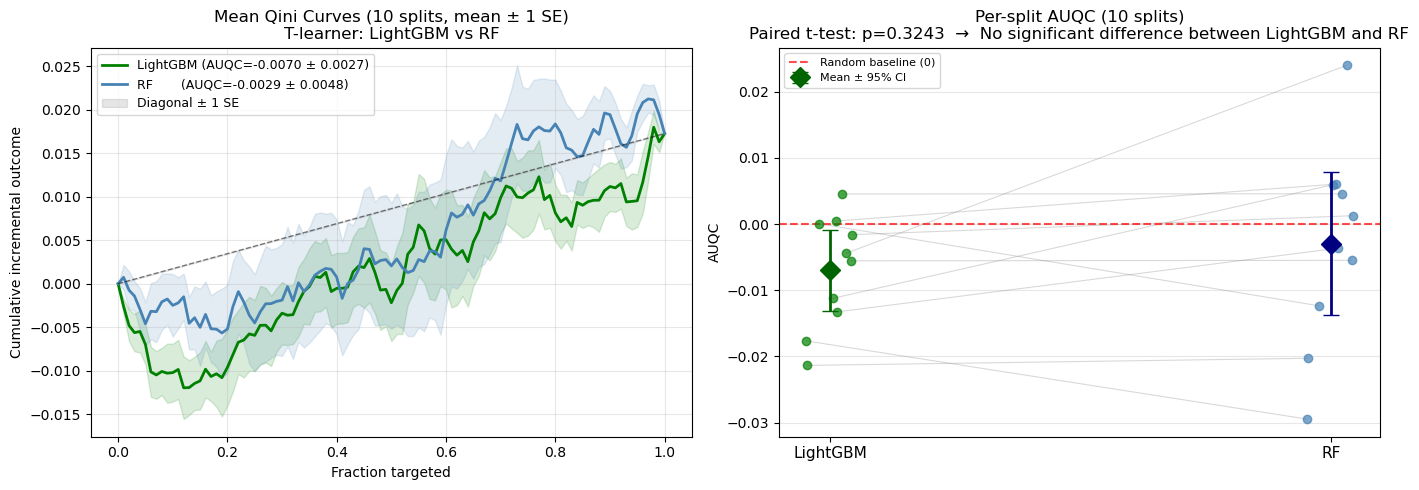

Note: higher Var(CATE_hat) for LightGBM does not mean better ranking —
it can reflect arm-level overfitting. AUQC on held-out splits is the ground truth.


In [24]:
curves_lgb_arr = np.array(curves_lgb_splits)
curves_rf_arr  = np.array(curves_rf_splits)

m_lgb_c = curves_lgb_arr.mean(axis=0);  s_lgb_c = curves_lgb_arr.std(axis=0) / np.sqrt(N_EVAL)
m_rf_c  = curves_rf_arr.mean(axis=0);   s_rf_c  = curves_rf_arr.std(axis=0)  / np.sqrt(N_EVAL)

diag_curves = np.array([x_grid_eval * g1 for g1 in g1_per_split])
diag_mean   = diag_curves.mean(axis=0)
diag_se     = diag_curves.std(axis=0) / np.sqrt(N_EVAL)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── (1) Mean Qini curves ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_grid_eval, m_lgb_c, color='green',     linewidth=2,
        label=f'LightGBM (AUQC={m_lgb:.4f} ± {se_lgb:.4f})')
ax.fill_between(x_grid_eval, m_lgb_c - s_lgb_c, m_lgb_c + s_lgb_c, color='green', alpha=0.15)
ax.plot(x_grid_eval, m_rf_c,  color='steelblue', linewidth=2,
        label=f'RF       (AUQC={m_rf:.4f} ± {se_rf:.4f})')
ax.fill_between(x_grid_eval, m_rf_c - s_rf_c, m_rf_c + s_rf_c, color='steelblue', alpha=0.15)
ax.fill_between(x_grid_eval, diag_mean - diag_se, diag_mean + diag_se,
                color='gray', alpha=0.2, label='Diagonal ± 1 SE')
ax.plot(x_grid_eval, diag_mean, 'k--', linewidth=1, alpha=0.5)
ax.set_title(f'Mean Qini Curves ({N_EVAL} splits, mean ± 1 SE)\nT-learner: LightGBM vs RF')
ax.set_xlabel('Fraction targeted')
ax.set_ylabel('Cumulative incremental outcome')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── (2) Per-split AUQC with paired lines ─────────────────────────────────────
ax = axes[1]
rng = np.random.default_rng(0)
x_jit = rng.uniform(-0.05, 0.05, N_EVAL)
ax.scatter(np.ones(N_EVAL) + x_jit,   auqc_lgb, color='green',     alpha=0.7, zorder=3)
ax.scatter(np.ones(N_EVAL)*2 + x_jit, auqc_rf,  color='steelblue', alpha=0.7, zorder=3)
for j in range(N_EVAL):
    ax.plot([1 + x_jit[j], 2 + x_jit[j]], [auqc_lgb[j], auqc_rf[j]],
            color='gray', alpha=0.3, linewidth=0.8)
ax.errorbar([1], [m_lgb], yerr=[[m_lgb - lo_lgb], [hi_lgb - m_lgb]],
            fmt='D', color='darkgreen', markersize=10, capsize=6, linewidth=2, zorder=5,
            label='Mean ± 95% CI')
ax.errorbar([2], [m_rf],  yerr=[[m_rf - lo_rf],   [hi_rf  - m_rf]],
            fmt='D', color='navy',      markersize=10, capsize=6, linewidth=2, zorder=5)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Random baseline (0)')
ax.set_xticks([1, 2]); ax.set_xticklabels(['LightGBM', 'RF'], fontsize=11)
ax.set_ylabel('AUQC')
ax.set_title(f'Per-split AUQC ({N_EVAL} splits)\nPaired t-test: p={p_diff:.4f}  →  {verdict}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ist3_auqc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Note: higher Var(CATE_hat) for LightGBM does not mean better ranking —")
print("it can reflect arm-level overfitting. AUQC on held-out splits is the ground truth.")


## 5. Feature Importance for Outcome and CATE

In [25]:
# ── Feature importance for outcome prediction (LightGBM on all data) ──────────
lgb_all = make_lgbm(params_all, seed=42)
lgb_all.fit(X, Y)
importances = pd.Series(lgb_all.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances = importances / importances.sum()  # normalise to sum to 1

print("=" * 60)
print("LightGBM Feature Importances (outcome Y, tuned on all data)")
print("=" * 60)
for feat, imp in importances.items():
    bar = "█" * int(imp * 200)
    print(f"  {feat:<25} {imp:.4f}  {bar}")

print()

# ── Feature importance difference between arms (proxy for HTE drivers) ────────
lgb0_fi = pd.Series(lgb0.feature_importances_, index=feature_cols)
lgb1_fi = pd.Series(lgb1.feature_importances_, index=feature_cols)
lgb0_fi = lgb0_fi / lgb0_fi.sum()
lgb1_fi = lgb1_fi / lgb1_fi.sum()
delta_imp = (lgb1_fi - lgb0_fi).abs().sort_values(ascending=False)

print("=" * 60)
print("Feature importance |arm1 - arm0|: proxy for HTE-driving features")
print("=" * 60)
for feat, d in delta_imp.items():
    bar = "█" * int(d * 500)
    print(f"  {feat:<25} {d:.4f}  {bar}")


LightGBM Feature Importances (outcome Y, tuned on all data)
  dbprand                   0.1736  ██████████████████████████████████
  age                       0.1614  ████████████████████████████████
  sbprand                   0.1614  ████████████████████████████████
  weight                    0.1486  █████████████████████████████
  nihss                     0.1325  ██████████████████████████
  glucose                   0.0632  ████████████
  gcs_score_rand            0.0436  ████████
  stroketype_2.0            0.0257  █████
  antiplat_rand             0.0218  ████
  gender                    0.0214  ████
  infarct                   0.0164  ███
  atrialfib_rand            0.0150  ███
  stroketype_4.0            0.0089  █
  stroketype_3.0            0.0064  █
  stroketype_5.0            0.0000  

Feature importance |arm1 - arm0|: proxy for HTE-driving features
  dbprand                   0.0354  █████████████████
  glucose                   0.0243  ████████████
  weight              

## 6. Visualizations

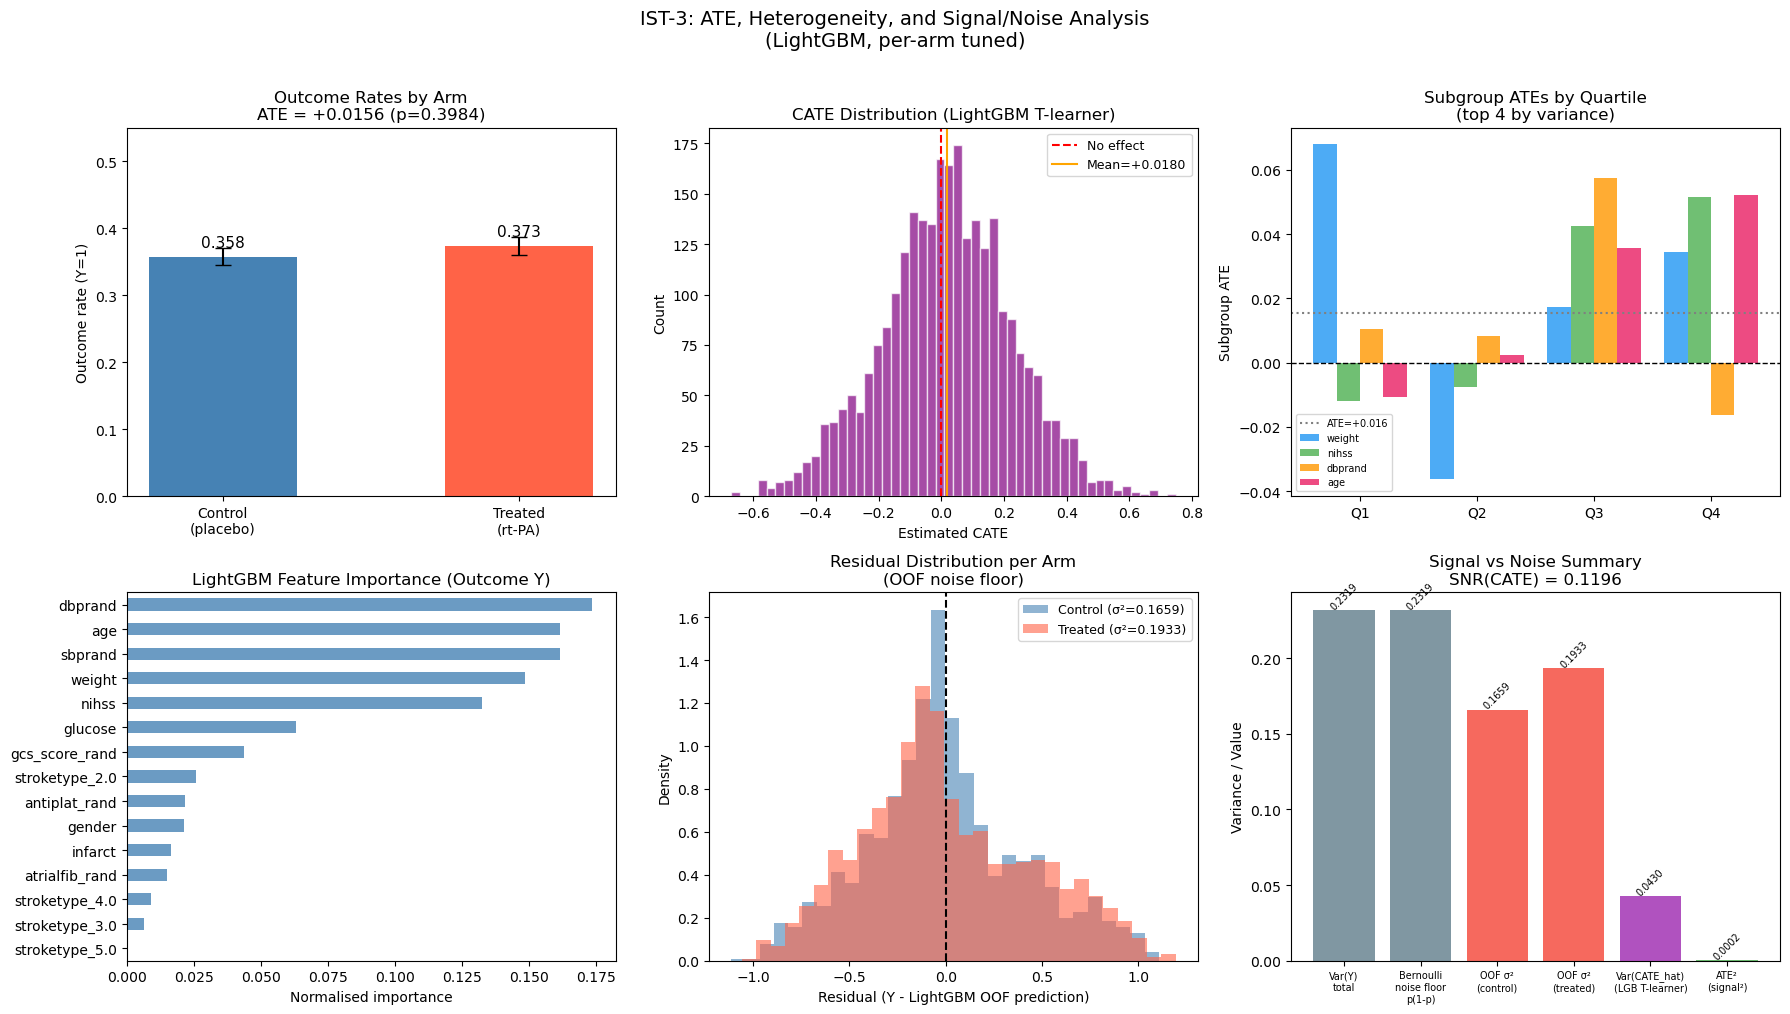

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── (1) Outcome rates by treatment arm ────────────────────────────────────────
ax = axes[0, 0]
rates = [Y0.mean(), Y1.mean()]
errs  = [np.sqrt(Y0.var(ddof=1)/n0), np.sqrt(Y1.var(ddof=1)/n1)]
bars = ax.bar(['Control\n(placebo)', 'Treated\n(rt-PA)'], rates, color=['steelblue', 'tomato'],
               yerr=errs, capsize=6, width=0.5)
ax.set_ylim(0, 0.55)
ax.set_ylabel('Outcome rate (Y=1)')
ax.set_title(f'Outcome Rates by Arm\nATE = {ate:+.4f} (p={p_val:.4f})')
for bar, r in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, r + 0.015, f'{r:.3f}', ha='center', fontsize=11)

# ── (2) CATE distribution ─────────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(cate_hat, bins=50, color='purple', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No effect')
ax.axvline(cate_hat.mean(), color='orange', linestyle='-', linewidth=1.5, label=f'Mean={cate_hat.mean():+.4f}')
ax.set_xlabel('Estimated CATE')
ax.set_ylabel('Count')
ax.set_title('CATE Distribution (LightGBM T-learner)')
ax.legend(fontsize=9)

# ── (3) Subgroup ATEs for top features ────────────────────────────────────────
ax = axes[0, 2]
top_feats = sorted(subgroup_summary, key=lambda x: x['var'], reverse=True)[:4]
x_pos = np.arange(4)
width = 0.2
colors_sub = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
for i, s in enumerate(top_feats):
    ax.bar(x_pos + i * width, s['ates'], width=width, label=s['feature'], color=colors_sub[i], alpha=0.8)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axhline(ate, color='gray', linestyle=':', linewidth=1.5, label=f'ATE={ate:+.3f}')
ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax.set_ylabel('Subgroup ATE')
ax.set_title('Subgroup ATEs by Quartile\n(top 4 by variance)')
ax.legend(fontsize=7)

# ── (4) Feature importances ───────────────────────────────────────────────────
ax = axes[1, 0]
importances.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('LightGBM Feature Importance (Outcome Y)')
ax.set_xlabel('Normalised importance')
ax.invert_yaxis()

# ── (5) Residual distribution per arm ────────────────────────────────────────
ax = axes[1, 1]
resid0_plot = Y[T == 0] - oof0
resid1_plot = Y[T == 1] - oof1
ax.hist(resid0_plot, bins=30, alpha=0.6, color='steelblue',
        label=f'Control (σ²={sigma0_sq:.4f})', density=True)
ax.hist(resid1_plot, bins=30, alpha=0.6, color='tomato',
        label=f'Treated (σ²={sigma1_sq:.4f})', density=True)
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Residual (Y - LightGBM OOF prediction)')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution per Arm\n(OOF noise floor)')
ax.legend(fontsize=9)

# ── (6) SNR summary ───────────────────────────────────────────────────────────
ax = axes[1, 2]
metrics = {
    'Var(Y)\ntotal': var_total,
    'Bernoulli\nnoise floor\np(1-p)': var_irreducible,
    'OOF σ²\n(control)': sigma0_sq,
    'OOF σ²\n(treated)': sigma1_sq,
    'Var(CATE_hat)\n(LGB T-learner)': var_cate_hat,
    'ATE²\n(signal²)': ate**2,
}
bar_colors = ['#607D8B', '#607D8B', '#F44336', '#F44336', '#9C27B0', '#4CAF50']
bars = ax.bar(range(len(metrics)), list(metrics.values()), color=bar_colors, alpha=0.8)
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(list(metrics.keys()), fontsize=7)
ax.set_ylabel('Variance / Value')
ax.set_title(f'Signal vs Noise Summary\nSNR(CATE) = {snr:.4f}')
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0005, f'{val:.4f}',
            ha='center', fontsize=7, rotation=45)

plt.suptitle('IST-3: ATE, Heterogeneity, and Signal/Noise Analysis\n(LightGBM, per-arm tuned)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('ist3_dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Summary: How Hard is CATE Estimation?

In [27]:
print("=" * 70)
print("SUMMARY: IST-3 — How hard is CATE estimation?")
print("=" * 70)
print()

# ── 1. ATE ────────────────────────────────────────────────────────────────────
print(f"1. Average Treatment Effect")
print(f"   Control (placebo) outcome rate:  {Y0.mean():.4f}  (n={n0})")
print(f"   Treated (rt-PA)   outcome rate:  {Y1.mean():.4f}  (n={n1})")
print(f"   ATE = {ate:+.4f}  SE={se_ate:.4f}")
print(f"   95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]  t={t_stat:.3f}  p={p_val:.4f}")
effect_size = abs(ate) / np.sqrt(var_irreducible)
print(f"   Cohen's h proxy = |ATE|/sqrt(p(1-p)) = {effect_size:.4f}")
if abs(ate) < 0.01:
    ate_label = "negligible"
elif abs(ate) < 0.03:
    ate_label = "very small"
elif abs(ate) < 0.07:
    ate_label = "small"
else:
    ate_label = "moderate"
print(f"   --> {'NOT statistically significant' if p_val >= 0.05 else 'Statistically significant'}, "
      f"{ate_label.upper()} effect")
print()

# ── 2. Outcome predictability ─────────────────────────────────────────────────
print(f"2. Outcome Predictability  [R² = fraction of Var(Y) explained by X]")
print(f"   Bernoulli noise floor p(1-p):  {var_irreducible:.4f}  (irreducible)")
print(f"   Outcome rate Y=1: {p_overall:.4f}  ({100*p_overall:.1f}%)")
print()
print(f"   {'Subset':<12}  {'Linear R²':>10}  {'LightGBM R²':>12}  {'n':>6}")
print(f"   {'-'*48}")
for key, label, n_ in [('all', 'All', len(Y)), ('control', 'Control', n0), ('treated', 'Treated', n1)]:
    print(f"   {label:<12}  {r2_results[key]['lr']:>10.4f}  {r2_results[key]['lgb']:>12.4f}  {n_:>6}")
print()
_r_ctrl = r2_results['control']['lgb']
_r_trt  = r2_results['treated']['lgb']
_r_all  = r2_results['all']['lgb']
print(f"   LightGBM explains ~{100*_r_all:.0f}% of outcome variance (R²={_r_all:.4f}).")
print(f"   The remaining ~{100*(1-_r_all):.0f}% is irreducible noise — dominant feature of this dataset.")
print(f"   R² is higher in the control arm ({_r_ctrl:.4f}) than treated ({_r_trt:.4f}),")
print(f"   suggesting rt-PA introduces additional outcome variability not captured by covariates.")
print(f"   Propensity std={prop_std:.4f} (range [{prop_min:.3f},{prop_max:.3f}]) confirms good RCT balance.")
print()

# ── 3. CATE heterogeneity ─────────────────────────────────────────────────────
sig_het = [s for s in subgroup_summary if s['p_interact'] < 0.05]
print(f"3. CATE Heterogeneity  [LightGBM T-learner, per-arm tuned]")
print(f"   CATE mean (≈ATE): {cate_hat.mean():+.4f}")
print(f"   CATE std:          {cate_hat.std():.4f}")
print(f"   CATE range:        [{cate_hat.min():+.4f}, {cate_hat.max():+.4f}]")
print(f"   % with CATE > 0 (predicted benefit): {100*(cate_hat > 0).mean():.1f}%")
print(f"   % with CATE < 0 (predicted harm):    {100*(cate_hat < 0).mean():.1f}%")
cv_str = f"{cate_hat.std()/abs(cate_hat.mean()):.2f}" if abs(cate_hat.mean()) > 1e-6 else "∞"
print(f"   CV = Std/|mean| = {cv_str}  (high CV → large relative spread around ATE)")
print(f"   Significant T×X interactions (F-test, p<0.05): {[s['feature'] for s in sig_het]}")
print(f"   Only nihss shows a significant interaction — heterogeneity is concentrated there.")
print()

# ── 4. Signal-to-noise ────────────────────────────────────────────────────────
print(f"4. Signal-to-Noise Ratio")
print(f"   Var(Y)            = {var_total:.5f}  (total outcome variance)")
print(f"   Noise floor       = {var_irreducible:.5f}  (Bernoulli p(1-p), irreducible)")
print(f"   OOF residual σ²   = {sigma0_sq:.5f} (control) / {sigma1_sq:.5f} (treated)  after LightGBM")
print(f"   ATE²              = {ate**2:.6f}  (mean treatment signal)")
print(f"   Var(CATE_hat)     = {var_cate_hat:.5f}  (upper bound on true CATE variance)")
print(f"   SNR_ATE  = ATE² / Var(Y)               = {ate**2 / var_total:.5f}")
print(f"   SNR_CATE = Var(CATE_hat) / noise_floor  = {snr:.5f}")
print()

# ── Bottom line ───────────────────────────────────────────────────────────────
print("=" * 70)
print("BOTTOM LINE")
print("=" * 70)
print(f"  ATE:        {ate:+.4f} — NOT significant (p={p_val:.4f}), very small effect size")
print(f"              (Cohen's h={effect_size:.4f}; 95% CI spans zero)")
print()
print(f"  Outcome     Linear R²={r2_results['all']['lr']:.4f}, LightGBM R²={_r_all:.4f} (full dataset)")
print(f"  predict-    Covariates explain only ~{100*_r_all:.0f}% of variance in Y;")
print(f"  ability:    ~{100*(1-_r_all):.0f}% is irreducible Bernoulli noise (p(1-p)={var_irreducible:.4f}).")
print(f"              R² is notably lower in the treated arm ({_r_trt:.4f} vs {_r_ctrl:.4f}),")
print(f"              meaning treatment adds outcome uncertainty beyond baseline covariates.")
print()
print(f"  CATE het.:  Var(CATE_hat)={var_cate_hat:.5f}, Std={cate_hat.std():.4f}.")
print(f"              {100*(cate_hat > 0).mean():.0f}% of patients have CATE>0, but spread is wide")
print(f"              and driven mainly by nihss (only significant T×X interaction).")
print()
print(f"  SNR:        SNR_ATE={ate**2/var_total:.5f}, SNR_CATE={snr:.5f}")
print(f"              Both are far below 0.1 — noise utterly dominates the signal.")
print(f"              The heterogeneity variance is ~{snr*100:.1f}% of the noise floor.")
print()
print(f"  VERDICT:    IST-3 is an EXTREMELY HARD uplift modeling problem.")
print(f"              The treatment effect is tiny and non-significant, outcome noise")
print(f"              overwhelms CATE signal by ~{1/snr:.0f}×, and the only detectable")
print(f"              heterogeneity modifier is nihss. Models must effectively denoise")
print(f"              a ~{100*ate:.1f}pp average effect from ~{100*np.sqrt(var_irreducible):.0f}pp of Bernoulli noise.")


SUMMARY: IST-3 — How hard is CATE estimation?

1. Average Treatment Effect
   Control (placebo) outcome rate:  0.3576  (n=1373)
   Treated (rt-PA)   outcome rate:  0.3732  (n=1364)
   ATE = +0.0156  SE=0.0184
   95% CI: [-0.0205, +0.0516]  t=0.845  p=0.3984
   Cohen's h proxy = |ATE|/sqrt(p(1-p)) = 0.0323
   --> NOT statistically significant, VERY SMALL effect

2. Outcome Predictability  [R² = fraction of Var(Y) explained by X]
   Bernoulli noise floor p(1-p):  0.2319  (irreducible)
   Outcome rate Y=1: 0.3654  (36.5%)

   Subset         Linear R²   LightGBM R²       n
   ------------------------------------------------
   All               0.2783        0.2214    2737
   Control           0.3154        0.2949    1373
   Treated           0.2300        0.1716    1364

   LightGBM explains ~22% of outcome variance (R²=0.2214).
   The remaining ~78% is irreducible noise — dominant feature of this dataset.
   R² is higher in the control arm (0.2949) than treated (0.1716),
   suggesting rt